In [1]:
from langchain_community.tools import ArxivQueryRun, WikipediaQueryRun
from langchain_community.utilities import WikipediaAPIWrapper, ArxivAPIWrapper

In [2]:
# Arxiv API Wrapper
api_wrapper_arxiv = ArxivAPIWrapper(top_k_results=2, doc_content_chars_max=500)
arxiv = ArxivQueryRun(api_wrapper=api_wrapper_arxiv)

print(arxiv.name)
print(arxiv.invoke("Attention is all you need"))

arxiv
Published: 2024-07-22
Title: Attention Is All You Need But You Don't Need All Of It For Inference of Large Language Models
Authors: Georgy Tyukin, Gbetondji J-S Dovonon, Jean Kaddour, Pasquale Minervini
Summary: The inference demand for LLMs has skyrocketed in recent months, and serving
models with low latencies remains challenging due to the quadratic input length
complexity of the attention layers. In this work, we investigate the effect of
dropping MLP and attention layers at inference time o


In [3]:
# Wikipedia API Wrapper
api_wrapper_wikipedia = WikipediaAPIWrapper(top_k_results=2, doc_content_chars_max=500)
wikipedia = WikipediaQueryRun(api_wrapper=api_wrapper_wikipedia)

print(wikipedia.name)
print(wikipedia.invoke("What is Machine Learning"))

wikipedia
Page: Machine learning
Summary: Machine learning (ML) is a field of study in artificial intelligence concerned with the development and study of statistical algorithms that can learn from data and generalise to unseen data, and thus perform tasks without explicit instructions. Within a subdiscipline in machine learning, advances in the field of deep learning have allowed neural networks, a class of statistical algorithms, to surpass many previous machine learning approaches in performance.
ML fi


In [4]:
import os 
from dotenv import load_dotenv
load_dotenv()

os.environ["TAVILY_API_KEY"] = os.getenv("TAVILY_API_KEY")
os.environ["OPENAI_API_KEY"] = os.getenv("OPENAI_API_KEY")


In [5]:
# Tavily Search Results Tool
from langchain_community.tools.tavily_search import TavilySearchResults
tavily = TavilySearchResults()

print(tavily.name)
print(tavily.invoke("Provide me latest new about Agentci Ai sept:4, 2025"))

C:\Users\heman\AppData\Local\Temp\ipykernel_6752\4199853005.py:3: LangChainDeprecationWarning: The class `TavilySearchResults` was deprecated in LangChain 0.3.25 and will be removed in 1.0. An updated version of the class exists in the :class:`~langchain-tavily package and should be used instead. To use it run `pip install -U :class:`~langchain-tavily` and import as `from :class:`~langchain_tavily import TavilySearch``.
  tavily = TavilySearchResults()


tavily_search_results_json
[{'title': 'Agentic commerce - The next legal frontier in AI-powered ...', 'url': 'https://www.tlt.com/insights-and-events/insight/agentic-commerce---the-next-legal-frontier-in-ai-powered-shopping/', 'content': 'This publication is intended for general guidance and represents our understanding of the relevant law and practice as at September 2025. Specific advice should be sought for specific cases. For more information see our terms & conditions.\n\nDate published\n\n04 September 2025\n\n#### Get in touch\n\nMichelle Sally\n\nMichelle Sally\n\nPartner\nLondon\n\nTom Sharpe\n\nTom Sharpe\n\nPartner\nLondon\n\nAlex Williamson \n\nAlex Williamson\n\nPartner\nManchester\n\nEmily Hinton\n\nEmily Hinton\n\nSenior Associate\nLondon', 'score': 0.7621591}, {'title': '5 Agentic AI Trends of 2025', 'url': 'https://www.tredence.com/blog/agentic-ai-trends', 'content': 'Even more compelling, Gartner forecasts that by 2029, agentic AI will autonomously resolve 80 percent o

In [6]:
# Combine all tools in a single list
tools = [arxiv, wikipedia, tavily]
print(tools)

[ArxivQueryRun(api_wrapper=ArxivAPIWrapper(arxiv_search=<class 'arxiv.Search'>, arxiv_exceptions=(<class 'arxiv.ArxivError'>, <class 'arxiv.UnexpectedEmptyPageError'>, <class 'arxiv.HTTPError'>), top_k_results=2, ARXIV_MAX_QUERY_LENGTH=300, continue_on_failure=False, load_max_docs=100, load_all_available_meta=False, doc_content_chars_max=500)), WikipediaQueryRun(api_wrapper=WikipediaAPIWrapper(wiki_client=<module 'wikipedia' from 'c:\\Users\\heman\\Desktop\\04 Complete Agentic AI Bootcamp With LangGraph And LangChain by Krish Naik\\09 LangGraph Components\\myenv\\Lib\\site-packages\\wikipedia\\__init__.py'>, top_k_results=2, lang='en', load_all_available_meta=False, doc_content_chars_max=500)), TavilySearchResults(api_wrapper=TavilySearchAPIWrapper(tavily_api_key=SecretStr('**********')))]


In [7]:
# Model
from langchain_openai import ChatOpenAI
llm = ChatOpenAI(model="gpt-4o")

In [8]:
# Binding all tools to LLM
llm_with_tools = llm.bind_tools(tools)
# print(llm_with_tools)

In [9]:
from langchain_core.messages import HumanMessage, AIMessage
from pprint import pprint

query = [HumanMessage(content="What is recent news about Agentci Ai")]
llm_with_tools.invoke(query).tool_calls


[{'name': 'tavily_search_results_json',
  'args': {'query': 'Agentci Ai recent news'},
  'id': 'call_0CtyT5OZsoY6fwSEFqntqkdj',
  'type': 'tool_call'}]

In [10]:
query = [HumanMessage(content="What is Machine Learning")]
llm_with_tools.invoke(query).tool_calls

[{'name': 'wikipedia',
  'args': {'query': 'Machine Learning'},
  'id': 'call_SmeW7qmhhgiec8ZSu6qEfRsJ',
  'type': 'tool_call'}]

In [11]:
# State
from typing import TypedDict, Annotated, List
from langchain_core.messages import AnyMessage
from langgraph.graph.message import add_messages

class ChatBotState(TypedDict):
    messages: Annotated[List[AnyMessage], add_messages]

In [12]:
# Entire Chatbot using LangGraph
from langgraph.graph import StateGraph, START, END
from IPython.display import Image, display
from langgraph.prebuilt import ToolNode, tools_condition

# Node def
def tool_calling_llm(state: ChatBotState):
    return { "messages": [llm_with_tools.invoke(state["messages"])]}

# State Graph
graph = StateGraph(ChatBotState)

# Node
graph.add_node("tool_calling_llm", tool_calling_llm)
graph.add_node("tools", ToolNode(tools))

# Edge
graph.add_edge(START, "tool_calling_llm")
graph.add_conditional_edges(
    "tool_calling_llm",
    # If the latest message (result) from assistant is a tool call -> tools_condition routes to tools
    # If the latest message (result) from assistant is a not a tool call -> tools_condition routes to END
    tools_condition
)
graph.add_edge("tools", END)

# Workflow
workflow = graph.compile()


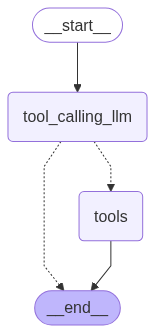

In [13]:
display(Image(workflow.get_graph().draw_mermaid_png()))

In [14]:
# Execution
initial_result = {"messages": [HumanMessage(content="what is weather today in nashik")]}

final_result = workflow.invoke(initial_result)

for m in final_result["messages"]:
    m.pretty_print()

================================ Human Message =================================

what is weather today in nashik
================================== Ai Message ==================================
Tool Calls:
  tavily_search_results_json (call_0kyZmslNnJ6Mjpc8nTPZfptz)
 Call ID: call_0kyZmslNnJ6Mjpc8nTPZfptz
  Args:
    query: Nashik weather today
================================= Tool Message =================================
Name: tavily_search_results_json

[{"title": "Nashik, Maharashtra, India 14 day weather forecast - Time and Date", "url": "https://www.timeanddate.com/weather/india/nashik/ext", "content": "| Thu Sep 18 |  | 80 / 70 °F | Passing showers. Overcast. | 83 °F | 10 mph | ↑ | 84% | 62% | 0.22\" | 3 (Moderate) | 6:22 am | 6:34 pm |\n|  |  |  |  |  |  |  |  |  |  |  |  |  |\n ---  ---  ---  ---  ---  --- \n| \\ Updated Thursday, September 4, 2025 2:53:45 pm Nashik time - Weather by CustomWeather, © 2025 | | | | | | | | | | | | | [...] |  | Conditions | | | Comfort | | | | 

In [15]:
# Execution
initial_result = {"messages": [HumanMessage(content="isbn:9780735211292")]}

final_result = workflow.invoke(initial_result)

for m in final_result["messages"]:
    m.pretty_print()

================================ Human Message =================================

isbn:9780735211292
================================== Ai Message ==================================
Tool Calls:
  tavily_search_results_json (call_eeiot1THaBrmopomeMKPmE9y)
 Call ID: call_eeiot1THaBrmopomeMKPmE9y
  Args:
    query: 9780735211292
================================= Tool Message =================================
Name: tavily_search_results_json

[{"title": "Atomic Habits: An Easy & Proven Way to Build Good Habits & Break ...", "url": "https://www.amazon.com/Atomic-Habits-Proven-Build-Break/dp/0735211299", "content": "Publisher\n  ‏\n  :\n  ‎\n   Avery\n Publication date\n  ‏\n  :\n  ‎\n   October 16, 2018\n Edition\n  ‏\n  :\n  ‎\n   First Edition\n Language\n  ‏\n  :\n  ‎\n   English\n Print length\n  ‏\n  :\n  ‎\n   320 pages\n ISBN-10\n  ‏\n  :\n  ‎\n   0735211299\n ISBN-13\n  ‏\n  :\n  ‎\n   978-0735211292\n Item Weight\n  ‏\n  :\n  ‎\n   1.13 pounds\n Dimensions\n  ‏\n  :\n  ‎\n   6.3 x 